# Testing the ```MandyocScen``` Class with basic examples

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Loading the MandyocScen class from the scenClasses module
from tapioca import MandyocScen as MS

## 1. Creating the Object

In [3]:
#Basic usage:

#Load a scenario with the variables of interest
scen = MS('example-continental_rift', name='Continental Rift',
                   variables=['density','temperature','viscosity','velocity','strain'],
                   xlimits=[50e3,1150e3], zlimits=[0e3,300e3], tlimits=[0,10],
                   load_lithology=True, load_surface=True, load_particles=True,
                  verbose=True)

#Recommended: correct the Z coordinate to match 0 at the air-surface interface
scen.correctZcoord()

display(scen.DTree)
print(f'DataTree size: {scen.DTree.nbytes/(1024**2):.3f} MB')

Scenario at: example-continental_rift
Scenario name: Continental Rift
x limits: [50000.0, 1150000.0]
z limits: [0.0, 300000.0]
time limits: [0, 10]
Variables loaded: density temperature viscosity velocity strain
Lithology loaded
Surface loaded
Particles [particles_trajectories.nc] loaded
Z coordinate corrected by subtracting 260000.0 m
New z limits: [-260000.0, 40000.0]


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [0.0, 300000.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vy           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float32 84B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    └── Group: /particles/original
            Dimensions:  (id: 3600, time: 21)
            Coordinates:
              * id       (id) int64 29kB 10017 10113 10180 10203 ... 1123118 1123153 1123223
              * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
            Data variables:
                x        (id, time) float64 605kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
                z        (id, time) float64 605kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
                layer    (id, time) float32 302kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
            Attributes:
                description:         particle trajectories
                reference timestep:  0.0myr (0)
                selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
                disclaimers:         some particles can change its layer over time (sedim...
                weak seed:           2

DataTree size: 5.255 MB


## Executing Post-processing Operations

Postprocessings may be executed through the ```scenPostProcessing``` class acessing the DataTree:

In [4]:
# Calculating the stress tensor field
scen.DTree.postproc.DeviatoricStressTensor()
display(scen.DTree.mesh['original'].ds)  # ds -> DataSet View

<xarray.DatasetView> Size: 4MB
Dimensions:      (time: 21, z: 31, x: 111)
Coordinates:
  * time         (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
  * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
  * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
Data variables:
    density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    viscosity    (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    vx           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    vy           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    strain       (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
    tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>

### Scenario manipulation and plotting

In [5]:
# selecting all data at 5 Myr and getting the original mesh dataset
CRTsel = scen.DTree.sel(time=5,method='nearest')
mesh = CRTsel.mesh['original'].ds # ds -> DataSet View

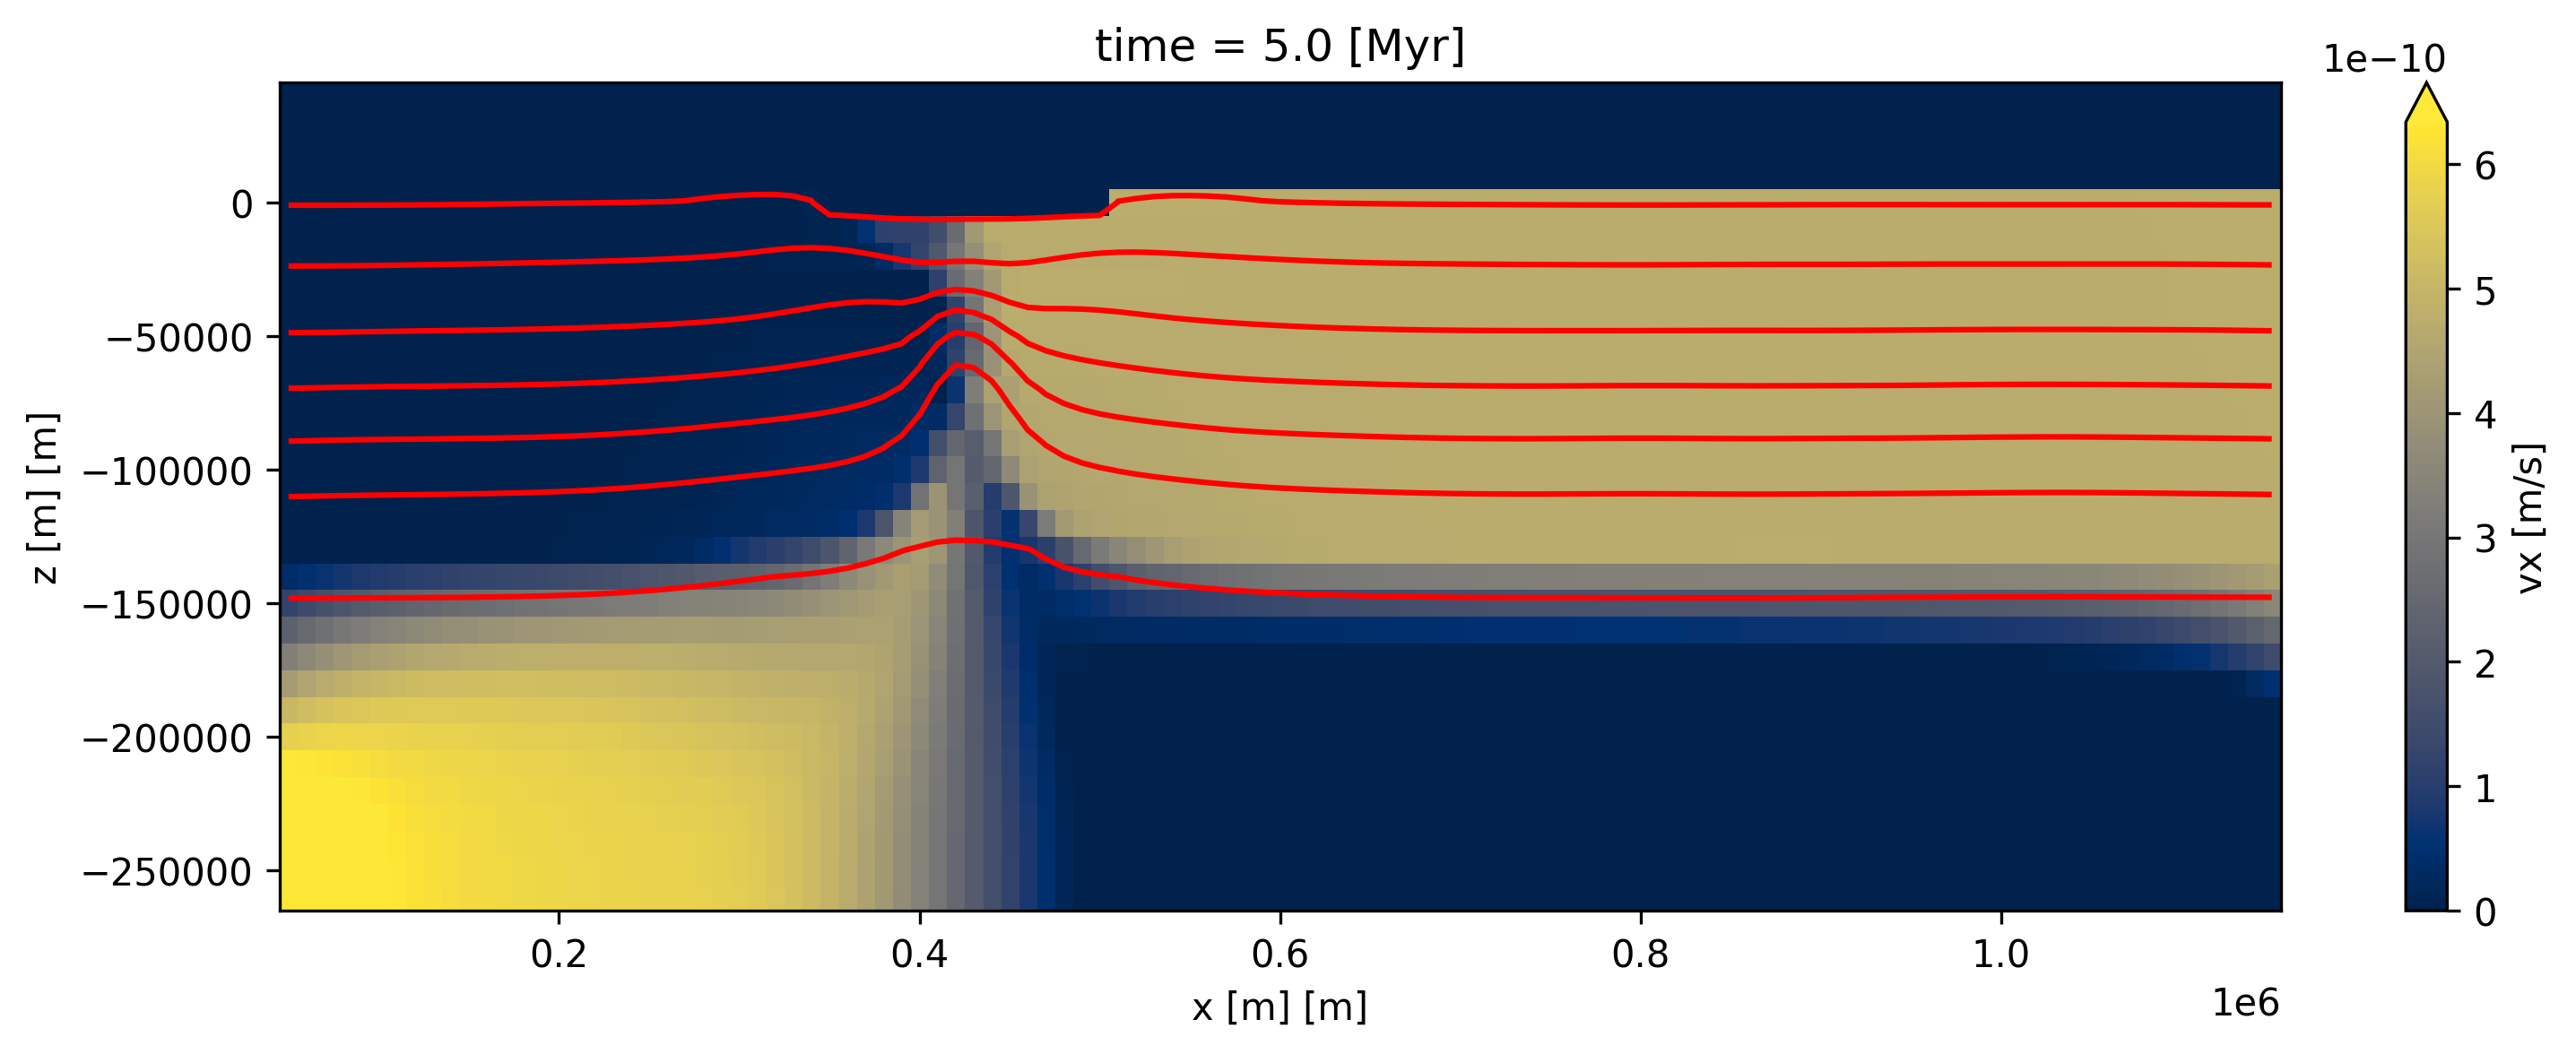

In [6]:
# plotting the velocity field and temperature contours through the xarray methods

plt.figure(figsize=(12,4), dpi=300)
mesh['vx'].plot.imshow(x='x',y='z', cmap='cividis', vmax=2/(60*60*24*365.25*100)) # convert cm/yr to m/s
mesh['temperature'].plot.contour(x='x',y='z',colors='red',levels=np.linspace(100,1300,7))

/home/jobueno/miniconda3/envs/test_tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)


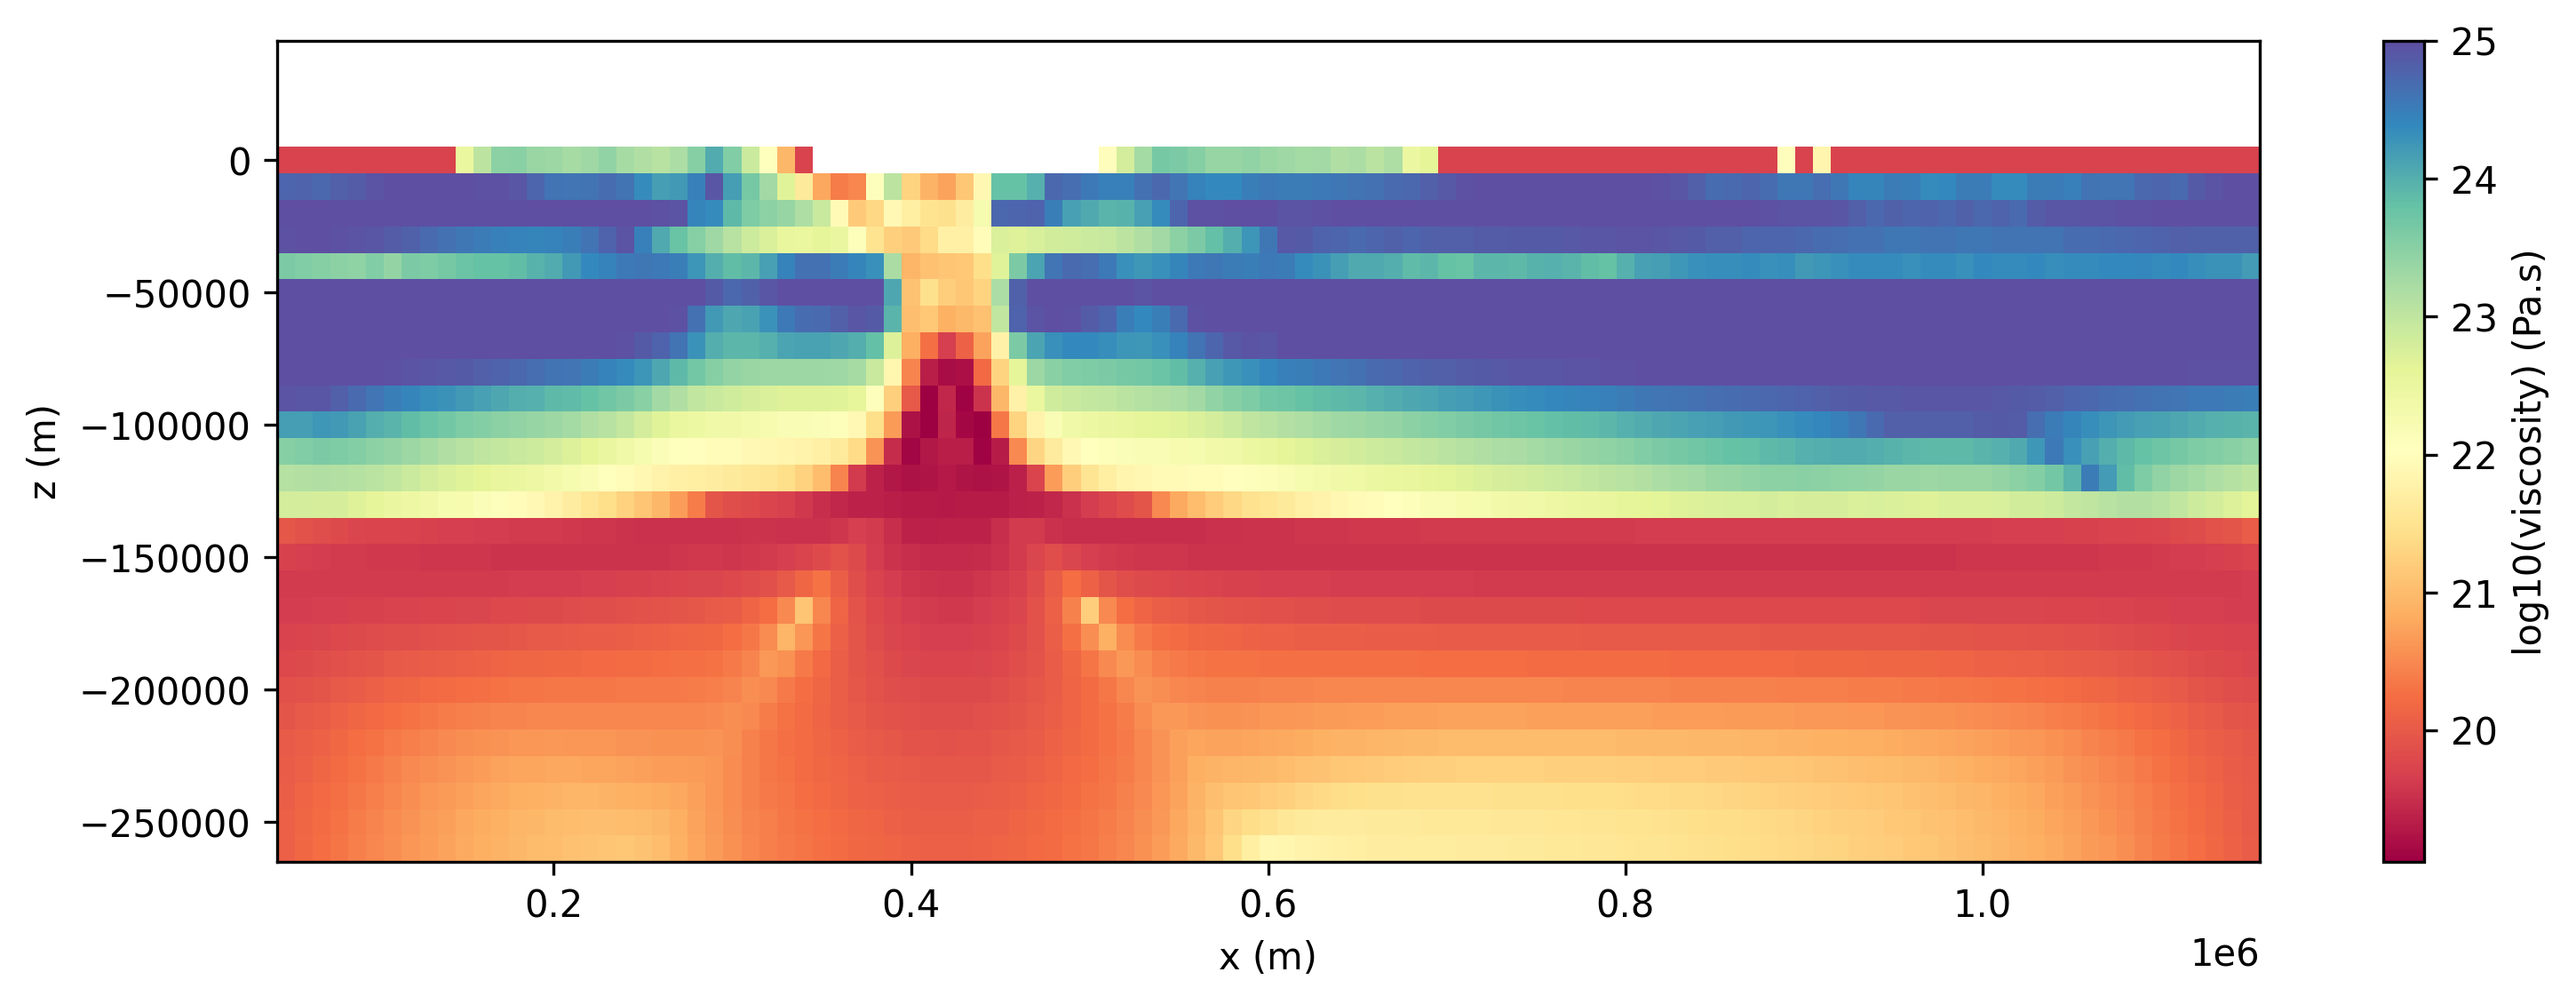

In [7]:
# plotting the viscosity field through the numpy and matplotlib methods 

visc = mesh['viscosity'] # selecting the viscosity field as an xarray DataArray

plt.figure(figsize=(12,4),dpi=300)
plt.pcolormesh(visc.x,visc.z, np.log10(visc), cmap='Spectral')
plt.xlabel('x (m)')
plt.ylabel('z (m)')
plt.colorbar(label='log10(viscosity) (Pa.s)')


## Particles manipulation

In [8]:
particles = CRTsel.particles['original'].ds # selecting the original particles dataset as an xarray DataSet
print(f'Number of particles: {int(particles.id.count())}')
display(particles)


Number of particles: 3600


<xarray.DatasetView> Size: 101kB
Dimensions:  (id: 3600)
Coordinates:
  * id       (id) int64 29kB 10017 10113 10180 10203 ... 1123118 1123153 1123223
    time     float64 8B 5.0
Data variables:
    x        (id) float64 29kB dask.array<chunksize=(3600,), meta=np.ndarray>
    z        (id) float64 29kB dask.array<chunksize=(3600,), meta=np.ndarray>
    layer    (id) float32 14kB dask.array<chunksize=(3600,), meta=np.ndarray>
Attributes:
    description:         particle trajectories
    reference timestep:  0.0myr (0)
    selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    disclaimers:         some particles can change its layer over time (sedim...
    weak seed:           2

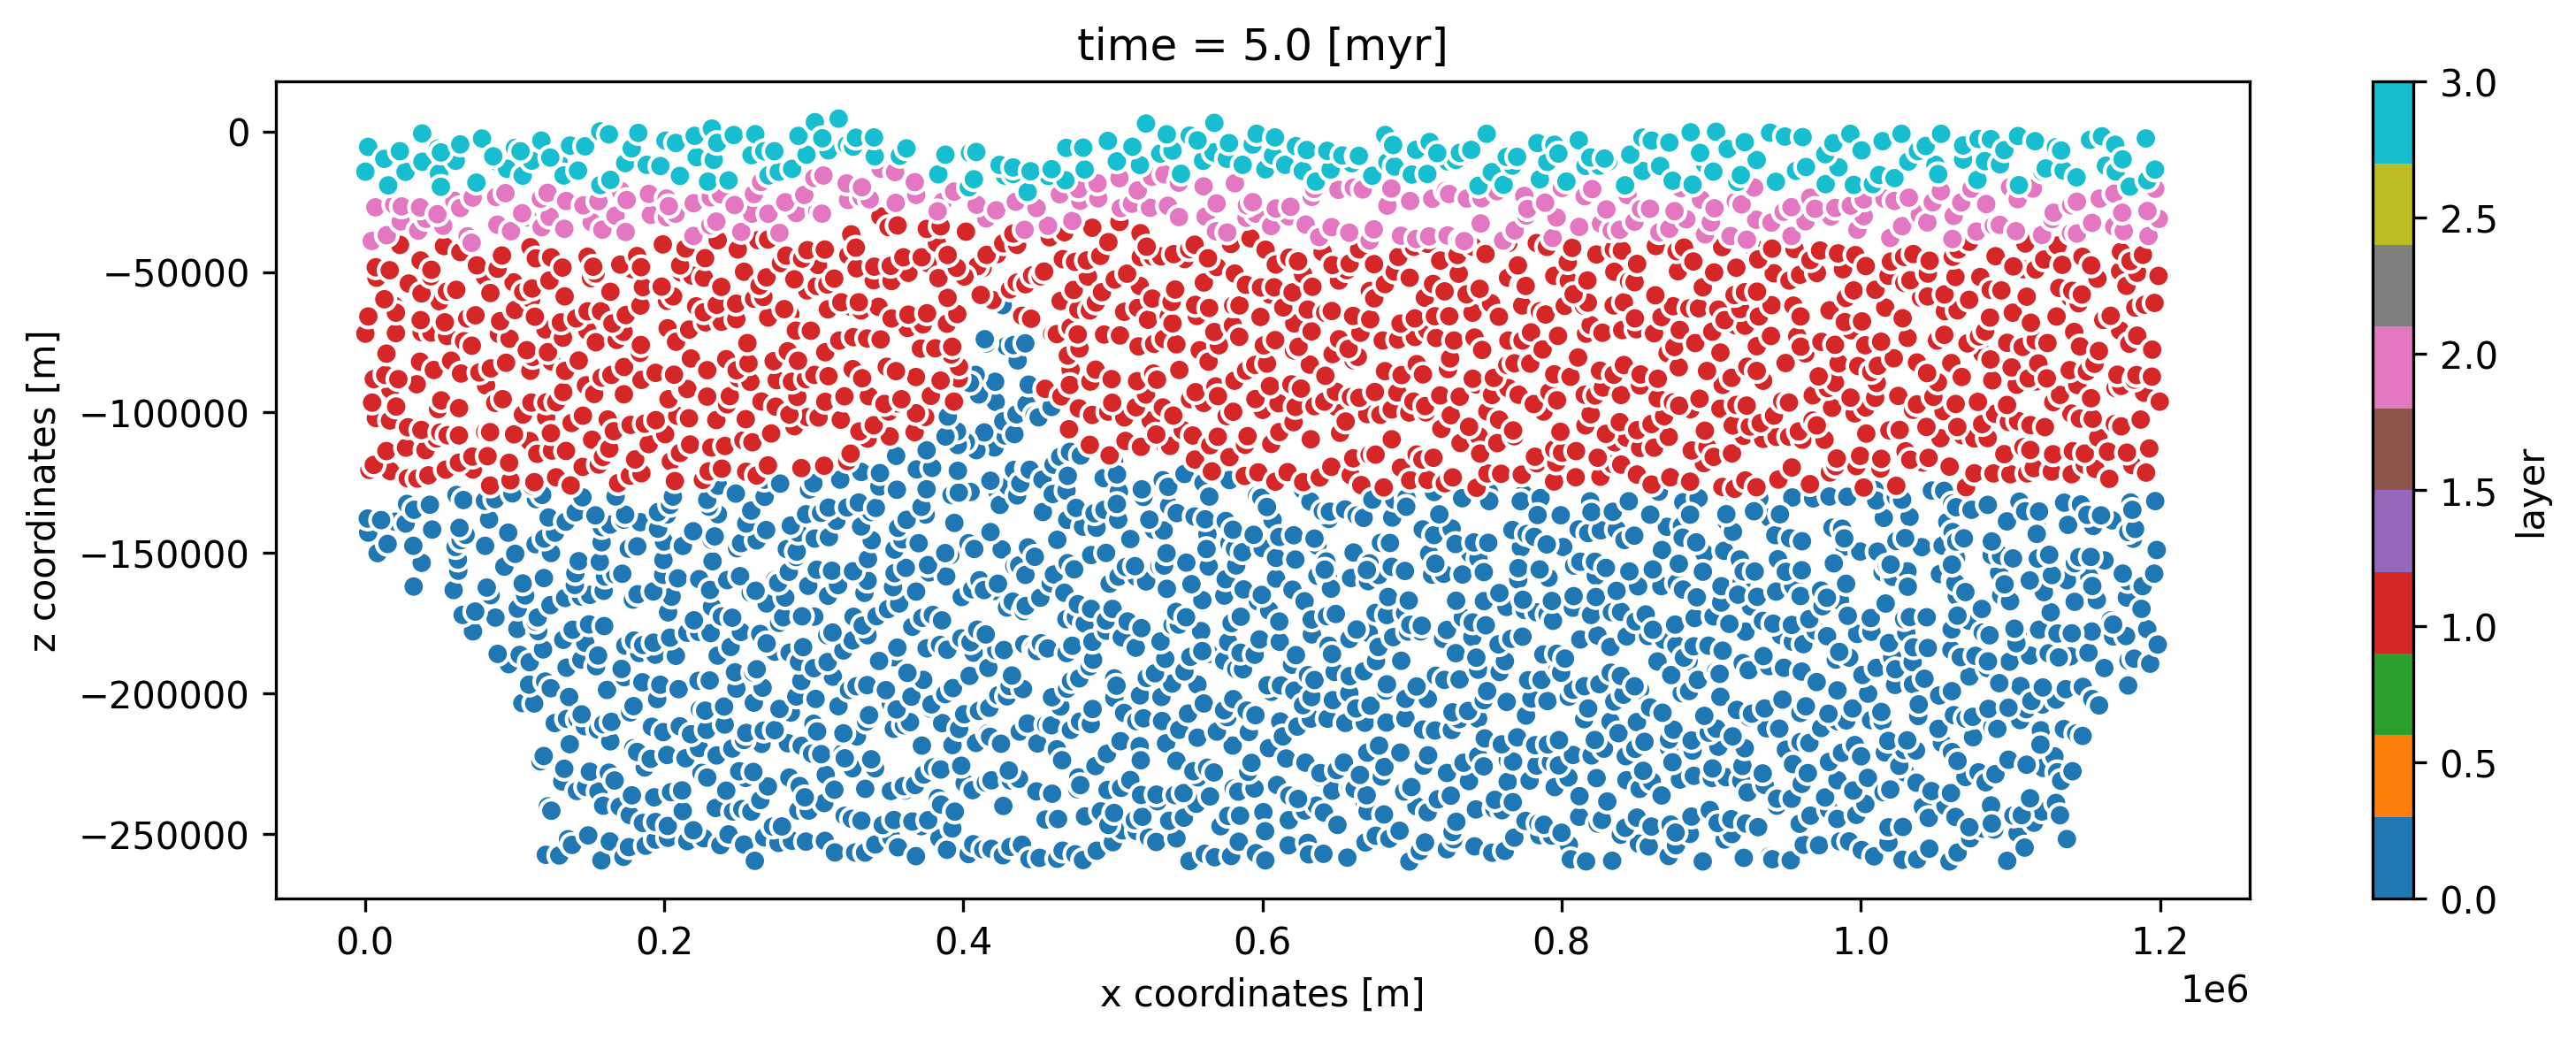

In [9]:
# plotting the particle positions colored by their layer index through the xarray methods
plt.figure(figsize=(12,4),dpi=300)
particles.plot.scatter(x='x',y='z',hue='layer',cmap='tab10')

In [10]:
# selecting particles by layer index (e.g., layers 2 and 3 for the crust) and creating a new selection named 'crust'
scen.selectParticles_bylayers([2,3],
                                 select_original=True, replace_original=False, 
                                 selection_name='crust')


crust_particles = scen.DTree.particles['crust'].ds
print(f'Crust particles: {int(crust_particles.id.count())}')
display(scen.DTree)


Crust particles: 480


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [0.0, 300000.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vy           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float32 84B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    ├── Group: /particles/original
    │       Dimensions:  (id: 3600, time: 21)
    │       Coordinates:
    │         * id       (id) int64 29kB 10017 10113 10180 10203 ... 1123118 1123153 1123223
    │         * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
    │       Data variables:
    │           x        (id, time) float64 605kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
    │           z        (id, time) float64 605kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
    │           layer    (id, time) float32 302kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
    │       Attributes:
    │           description:         particle trajectories
    │           reference timestep:  0.0myr (0)
    │           selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    │           disclaimers:         some particles can change its layer over time (sedim...
    │           weak seed:           2
    └── Group: /particles/crust
            Dimensions:  (id: 480, time: 21)
            Coordinates:
              * id       (id) int64 4kB 95912 95978 96046 96115 ... 1108001 1108068 1108122
              * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
            Data variables:
                x        (id, time) float64 81kB dask.array<chunks

In [11]:
# selecting 'crust' particles by their coordinates at 5 Myr and creating a new selection named 'central'
scen.selectParticles_bycoords(xlim=[300e3,700e3], zlim=[-150e3,5e3],tsel=5,
                                 selected_name='crust',replace_original=False, 
                                 selection_name='central')
central_particles = scen.DTree.particles['central'].ds
print(f'Central crust particles: {int(central_particles.id.count())}')
display(scen.DTree)

Central crust particles: 618


<xarray.DataTree>
Group: /
│   Attributes:
│       name:     Continental Rift
│       xlimits:  [50000.0, 1150000.0]
│       zlimits:  [0.0, 300000.0]
│       tlimits:  [0, 10]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 21, z: 31, x: 111)
│   │       Coordinates:
│   │         * time         (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
│   │         * z            (z) float32 124B -2.6e+05 -2.5e+05 -2.4e+05 ... 3e+04 4e+04
│   │         * x            (x) float32 444B 5e+04 6e+04 7e+04 ... 1.14e+06 1.15e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           viscosity    (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vx           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           vy           (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           strain       (time, z, x) float32 289kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xx       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_zz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_xz       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   │           tau_J2       (time, z, x) float64 578kB dask.array<chunksize=(21, 31, 111), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 21, z: 151, x: 551)
│           Coordinates:
│             * time       (time) float32 84B 0.0 0.5 1.0 1.5 ... 8.497 8.997 9.497 9.997
│             * z          (z) float32 604B -2.6e+05 -2.58e+05 -2.56e+05 ... 3.8e+04 4e+04
│             * x          (x) float32 2kB 5e+04 5.2e+04 5.4e+04 ... 1.148e+06 1.15e+06
│           Data variables:
│               lithology  (time, z, x) int8 2MB dask.array<chunksize=(21, 151, 551), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 21, x: 5501)
│           Coordinates:
│             * time     (time) float32 84B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
│             * x        (x) float32 22kB 5e+04 5.02e+04 5.04e+04 ... 1.15e+06 1.15e+06
│           Data variables:
│               surface  (time, x) float32 462kB dask.array<chunksize=(21, 5501), meta=np.ndarray>
└── Group: /particles
    ├── Group: /particles/original
    │       Dimensions:  (id: 3600, time: 21)
    │       Coordinates:
    │         * id       (id) int64 29kB 10017 10113 10180 10203 ... 1123118 1123153 1123223
    │         * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
    │       Data variables:
    │           x        (id, time) float64 605kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
    │           z        (id, time) float64 605kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
    │           layer    (id, time) float32 302kB dask.array<chunksize=(3600, 21), meta=np.ndarray>
    │       Attributes:
    │           description:         particle trajectories
    │           reference timestep:  0.0myr (0)
    │           selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
    │           disclaimers:         some particles can change its layer over time (sedim...
    │           weak seed:           2
    ├── Group: /particles/crust
    │       Dimensions:  (id: 480, time: 21)
    │       Coordinates:
    │         * id       (id) int64 4kB 95912 95978 96046 96115 ... 1108001 1108068 1108122
    │         * time     (time) float64 168B 0.0 0.5 1.0 1.5 2.0 ... 8.497 8.997 9.497 9.997
    │       Data variables:
    │           x        (id, time) float64 81kB dask.array<chunks

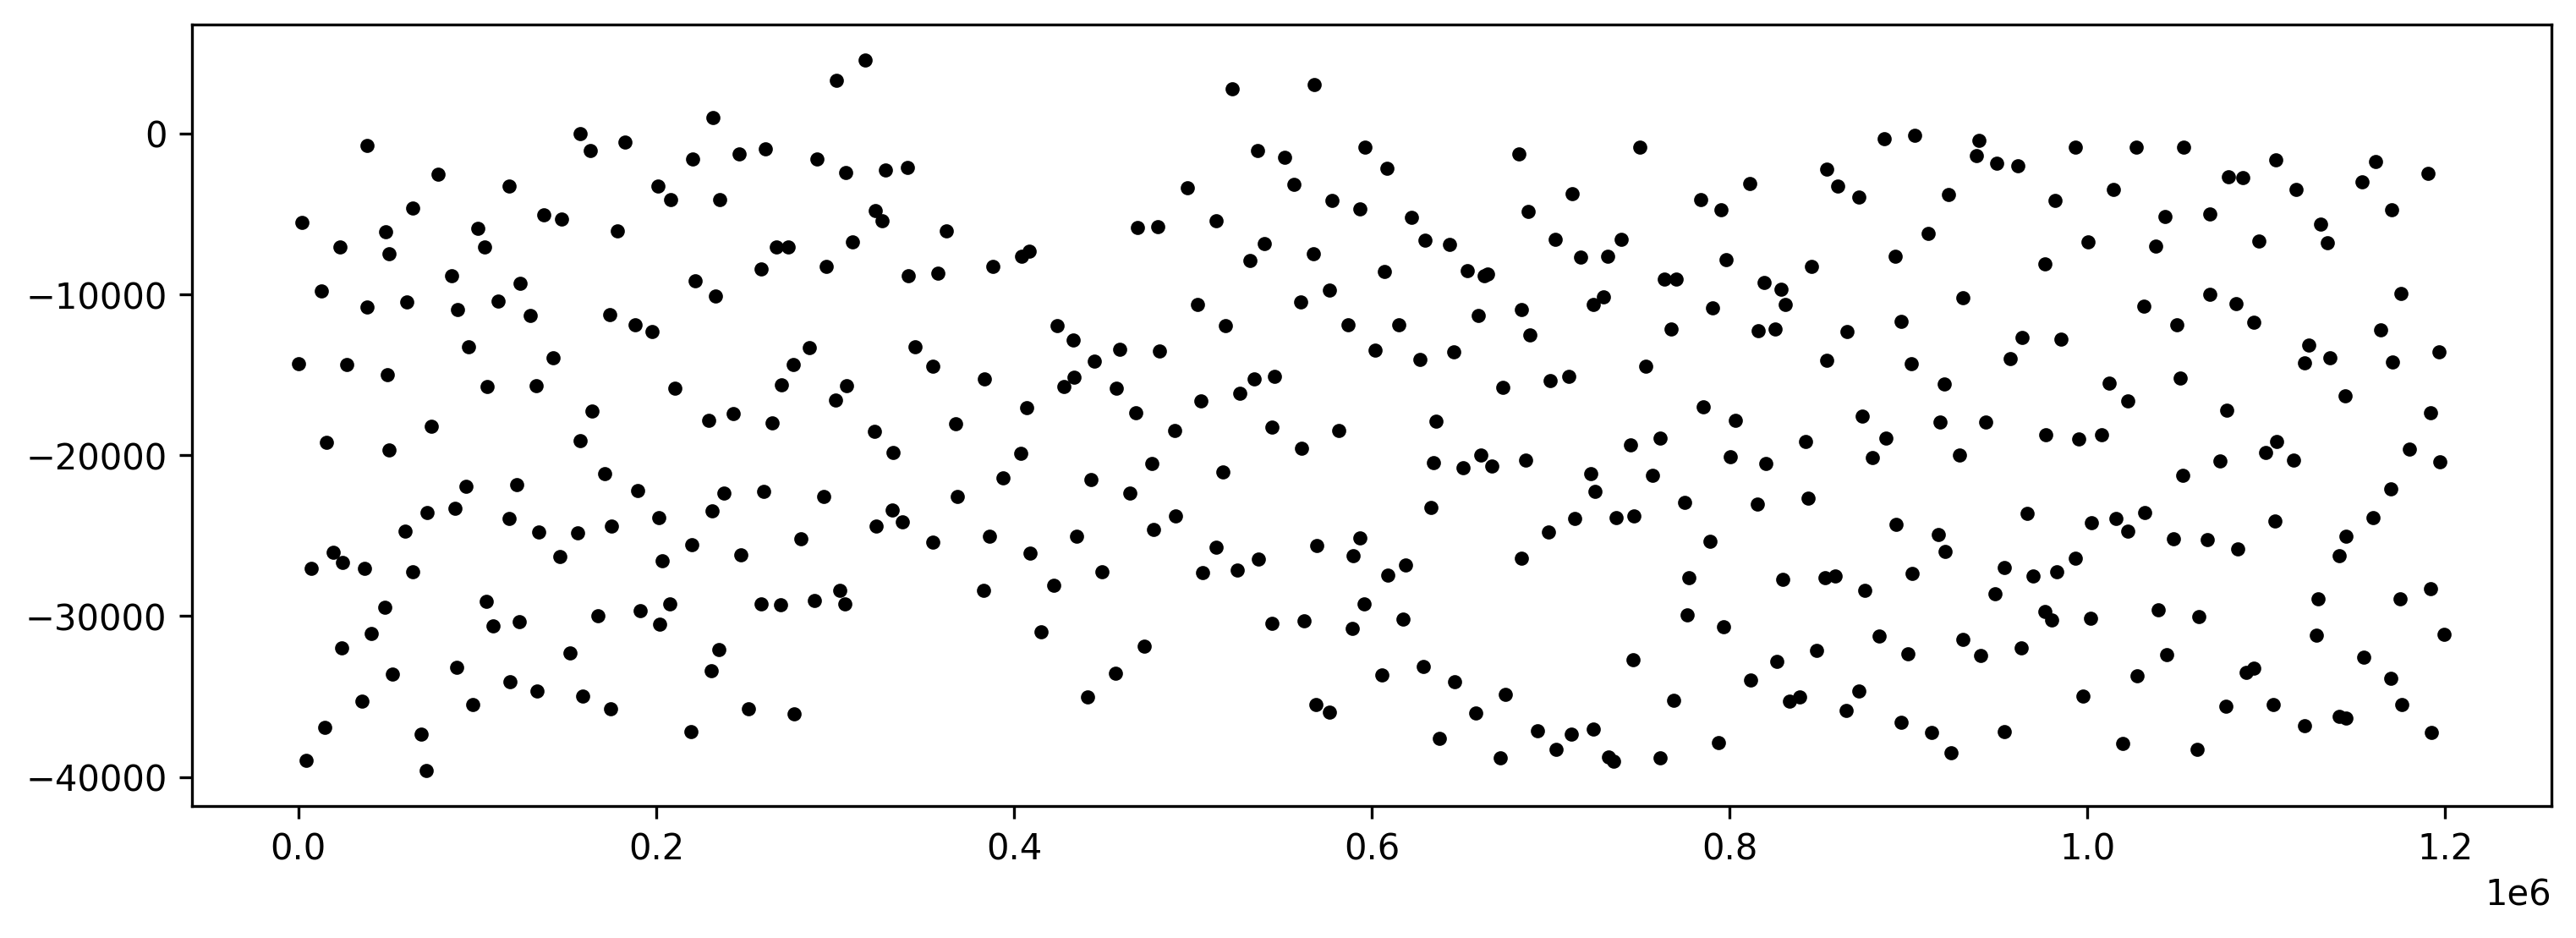

In [12]:
crust_t = crust_particles.sel(time=5, method='nearest') #selecting the crust particles at 5 Myr to plot their positions

# plotting the crust particle positions at 5 Myr through the matplotlib functions
plt.figure(figsize=(12,4),dpi=300)
plt.plot(crust_t.x, crust_t.z, marker='.',linestyle='None', color='black')

### A "fully" plot using the upscaled lithology tracked

Matplotlib has the best framework and is recommended for a fully customisable plot, while the ```MandyocPlotter``` is being developed. 

/home/jobueno/miniconda3/envs/test_tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)
/home/jobueno/miniconda3/envs/test_tapioca/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log10
  return self.func(*new_argspec)


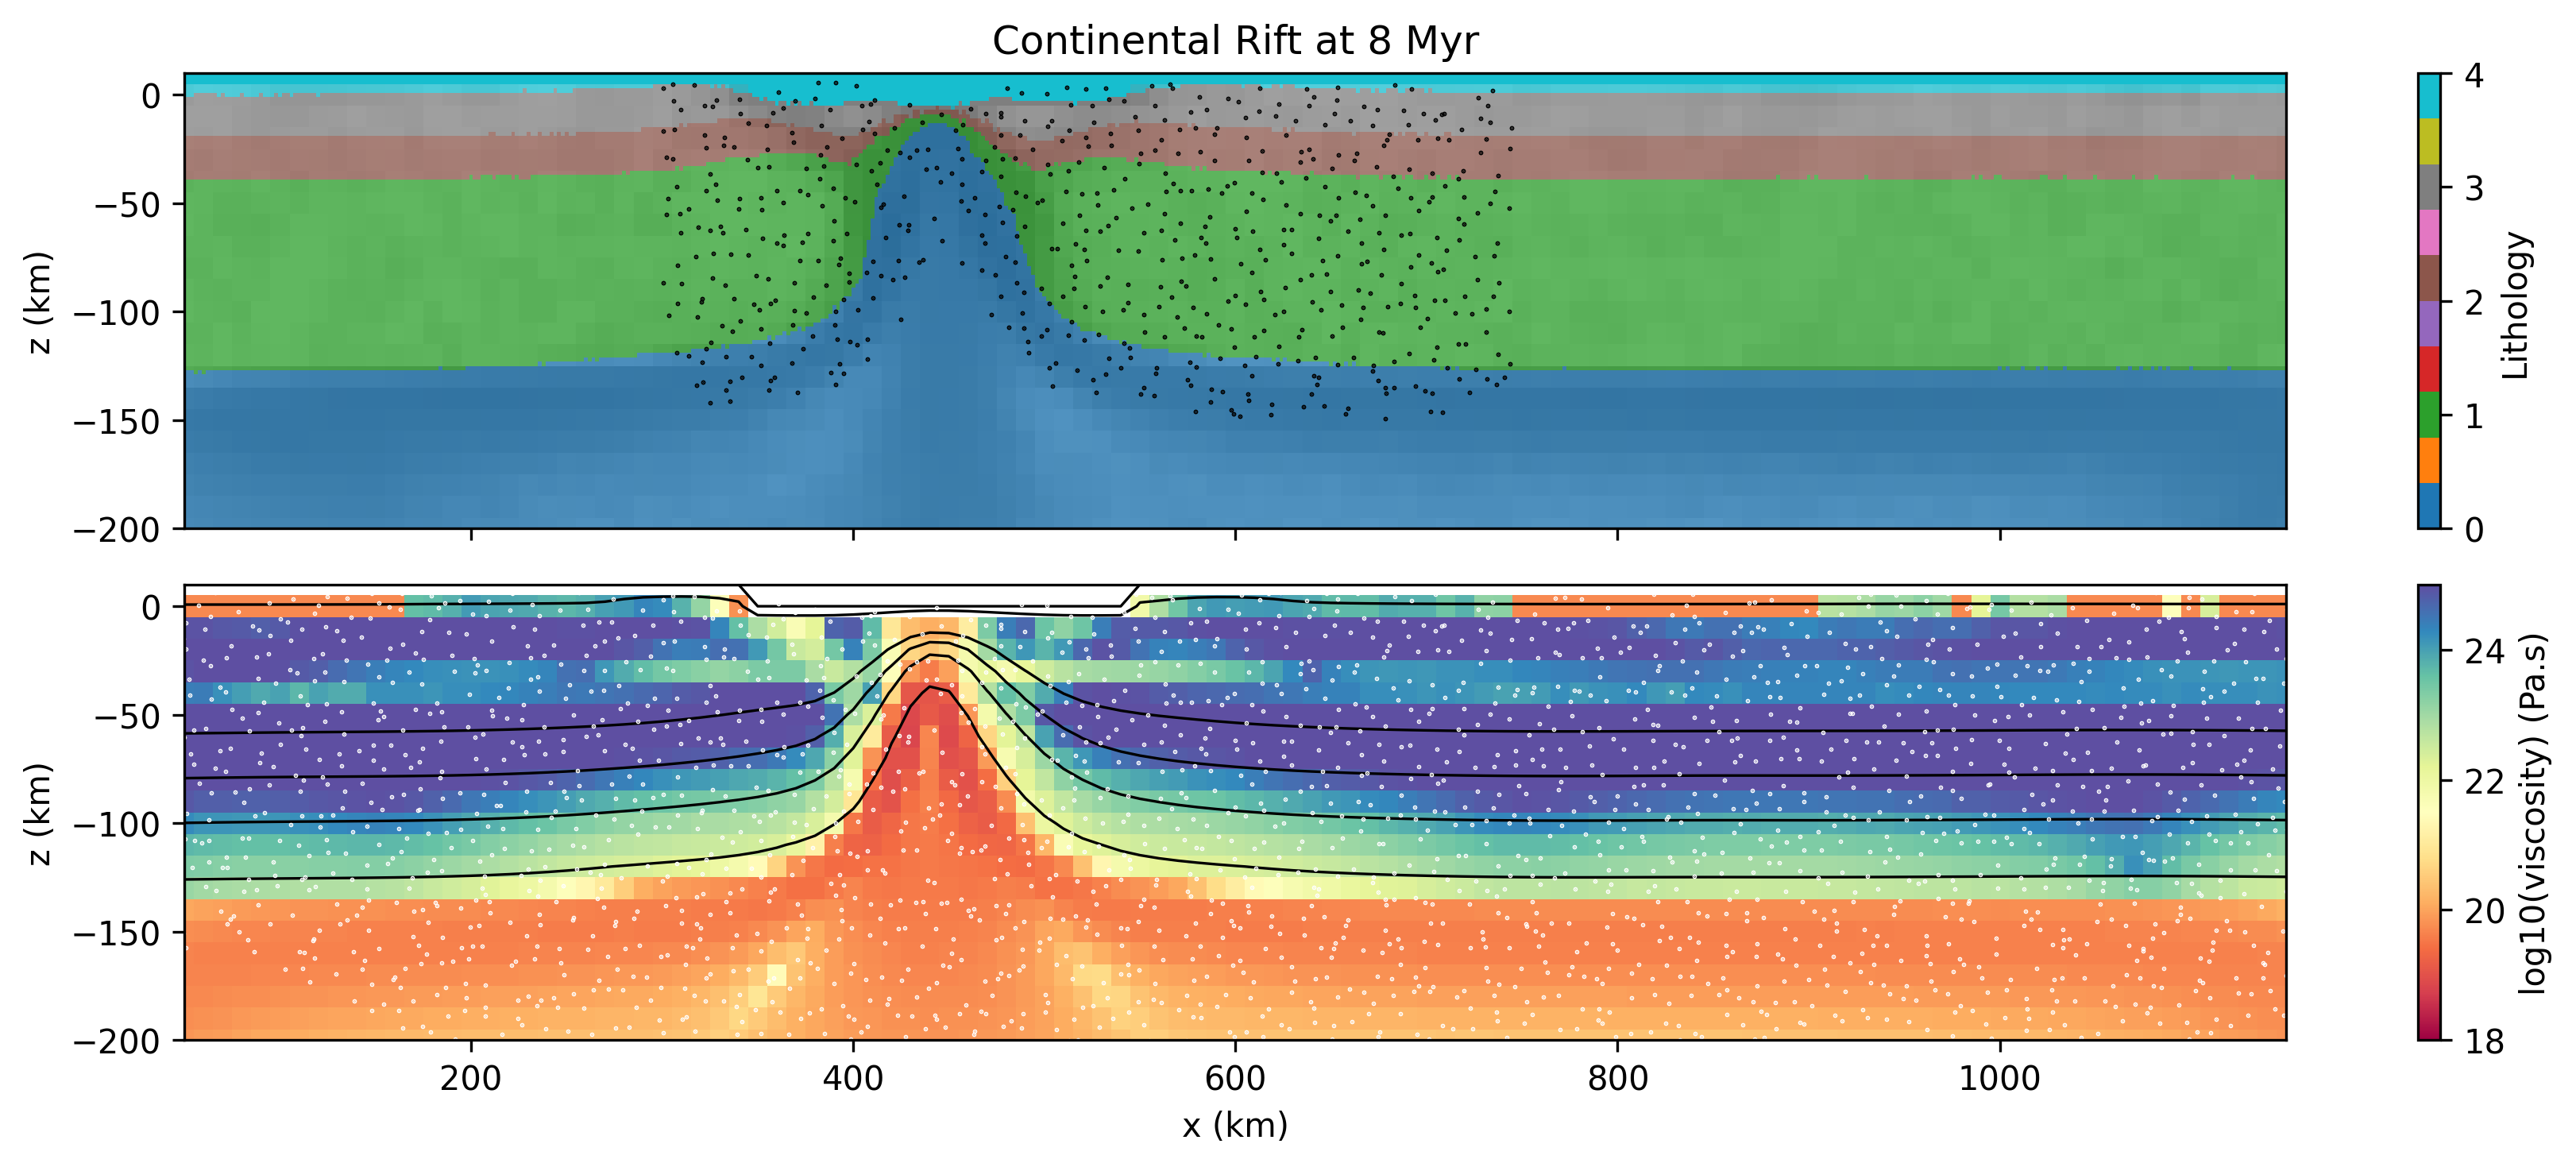

In [13]:
CRTsel = scen.DTree.sel(time=8,method='nearest') #Selecting the all data at 8 Myr
km = 1/1e3 # conversion factor to km for plotting

# Auxiliary variables to simplify the plotting code below
mesh = CRTsel.mesh['original'].ds
litho = CRTsel.mesh['upscaled'].ds
particles = CRTsel.particles['original'].ds
central = CRTsel.particles['central'].ds

# Figure with 2 axes
fig, axs = plt.subplots(2,1,figsize=(12,5),dpi=300, sharex=True, sharey=True)
ax_1, ax_2 = axs

# Axes 1: Lithology, strain, and central particles
litho_plot = ax_1.pcolormesh(litho.x*km,litho.z*km, litho['lithology'], cmap='tab10')
ax_1.pcolormesh(mesh.x*km,mesh.z*km, np.log10(mesh['strain']), cmap='Grays', vmin=-1, vmax=1, alpha=0.25)
ax_1.plot(central.x*km, central.z*km, marker='.',linestyle='None', color='black', markersize=0.8)

# Axes 2: Viscosity, temperature contours, and all particles
visc_plot = ax_2.pcolormesh(mesh.x*km,mesh.z*km, np.log10(mesh['viscosity']), cmap='Spectral',vmin=18,vmax=25)
ax_2.contour(mesh.x*km,mesh.z*km, mesh['temperature'], colors='black', levels=[0,100,600,800,1000,1200,1350],linewidths=0.8)
ax_2.plot(particles.x*km, particles.z*km, marker='.',linestyle='None', color='white', markersize=0.7)

# Minor customisations:
plt.colorbar(litho_plot, ax=ax_1, label='Lithology')
plt.colorbar(visc_plot, ax=ax_2, label='log10(viscosity) (Pa.s)')

ax_1.set_xlim(50,1150)
ax_1.set_ylim(-200,10)

ax_1.set_title('Continental Rift at 8 Myr')
ax_1.set_ylabel('z (km)')
ax_2.set_xlabel('x (km)')
ax_2.set_ylabel('z (km)')

fig.tight_layout()
plt.show()